In [23]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict

In [24]:
#define state
class BMIState(TypedDict):
    weight_kg : float
    height_m : float
    bmi : float
    verdict : str


In [29]:
def calculate_bmi(state : BMIState)-> BMIState:
    w = state ['weight_kg']
    h = state ['height_m']
    bmi = w / (h ** 2)
    state['bmi'] = round(bmi, 2)
    return state
def bmi_verdict(state:BMIState)->BMIState:
    if state['bmi'] < 18.5:
        state["verdict"] = "under weight"
    elif state['bmi']> 30 :
        state["verdict"] = "over weight"
    else:
        state["verdict"] = "healthy"
    return state



In [30]:
#define graph
graph = StateGraph(BMIState)

#add nodes

graph.add_node('calculate_bmi' , calculate_bmi)
graph.add_node('bmi_verdict',bmi_verdict)
#add edges

graph.add_edge(START, 'calculate_bmi')
graph.add_edge('calculate_bmi','bmi_verdict')
graph.add_edge('bmi_verdict',END)

#compile graph
workflow = graph.compile()

In [31]:
#execute the graph
initial_state = {'weight_kg':60,'height_m':1.7}
final_state= workflow.invoke(initial_state)
print(final_state)

{'weight_kg': 60, 'height_m': 1.7, 'bmi': 20.76, 'verdict': 'healthy'}


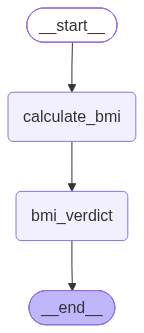

In [32]:
# display graph
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())
